# 미니 프로젝트 : 가위바위보 분류기 ✌️✊✋

# 필요한 라이브러리 임포트

In [54]:
import tensorflow as tf
from tensorflow import keras
import numpy as np 

import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import glob
import os
import matplotlib.pyplot as plt

print(tf.__version__)
print(np.__version__)

2.15.0
1.26.4


# 데이터 준비

- 가위, 바위, 보 각각 100장의 이미지 준비
- 구글의 [teachable machine](https://teachablemachine.withgoogle.com/) 사이트에서 쉽게 데이터를 만들어볼 수 있다

In [55]:
# 데이터 크기 확인

img = Image.open('data/scissor/0.jpg')

img_array = np.array(img)

img_array.shape

(28, 28, 3)

In [56]:
# 28 X 28 크기로 Resize

def resize_images(img_path):
    images = glob.glob(img_path + '/*.jpg')

    print(len(images), " images to be resized.")

    target_size = (28,28)
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize(target_size, Image.LANCZOS)
        new_img.save(img, 'JPEG')
    
    print(len(images), " imgaes resized.")

image_dir_path = "data/scissor"
image_dir_path2 = "data/scissor2"

resize_images(image_dir_path)
resize_images(image_dir_path2)

print("가위 이미지 resize 완료!")

100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
가위 이미지 resize 완료!


In [57]:
# 바위, 보 이미지도 동일하게 resize
resize_images("data/rock")
resize_images("data/rock2")

# 보
resize_images("data/paper")
resize_images("data/paper2")

100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.


All data shape: (300, 28, 28, 3)
All label shape: (300,)
label distribution: scissor=100, rock=100, paper=100


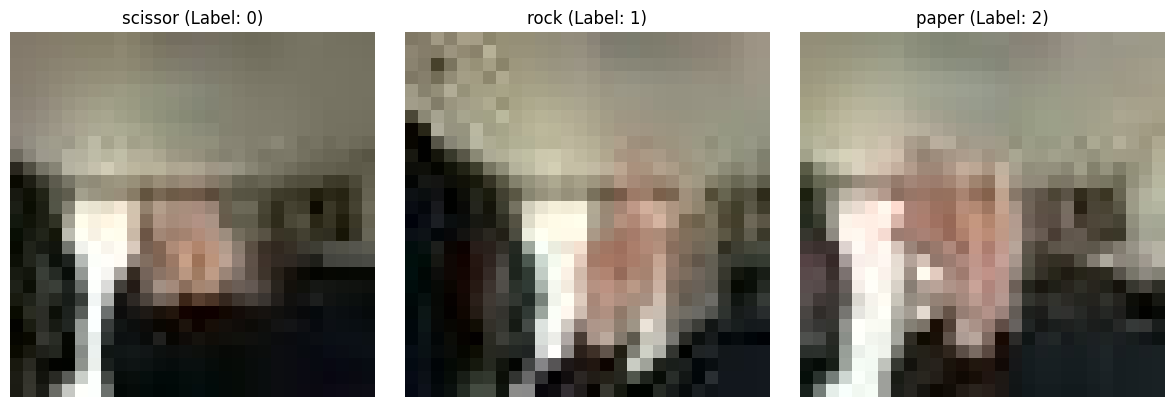

In [58]:
# 이미지를 받아 데이터를 읽게 하는 load_data 함수

def load_data(img_path, number_of_data = 300):

    img_size = 28
    color = 3

    imgs = np.zeros(number_of_data * img_size * img_size * color, dtype = np.int32).reshape(number_of_data, img_size, img_size, color)
    
    # 레이블 배열 초기화
    labels = np.zeros(number_of_data, dtype = np.int32)
    
    # 이미지 파일 읽기
    images = glob.glob(img_path + '/*.jpg')
    
    # 각 이미지를 배열에 저장
    for idx, img_file in enumerate(images[:number_of_data]):
        img = Image.open(img_file)
        imgs[idx] = np.array(img)
    
    return imgs, labels

# 가위, 바위, 보 데이터 로드

# 가위 (label: 0)
scissor_imgs, _ = load_data('data/scissor', 100)
scissor_labels = np.zeros(100, dtype=np.int32)

# 바위 (label: 1)
rock_imgs, _ = load_data('data/rock', 100)
rock_labels = np.ones(100, dtype=np.int32)

# 보 (label: 2)
paper_imgs, _ = load_data('data/paper', 100)
paper_labels = np.full(100, 2, dtype=np.int32)

# 모든 데이터 병합
X = np.concatenate([scissor_imgs, rock_imgs, paper_imgs], axis=0)
y = np.concatenate([scissor_labels, rock_labels, paper_labels], axis=0)

print(f"All data shape: {X.shape}")
print(f"All label shape: {y.shape}")
print(f"label distribution: scissor={np.sum(y==0)}, rock={np.sum(y==1)}, paper={np.sum(y==2)}")


# 데이터 시각화로 확인
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 각 클래스별로 하나씩 샘플 출력
axes[0].imshow(X[0])
axes[0].set_title(f'scissor (Label: {y[0]})')
axes[0].axis('off')

axes[1].imshow(X[100])
axes[1].set_title(f'rock (Label: {y[100]})')
axes[1].axis('off')

axes[2].imshow(X[200])
axes[2].set_title(f'paper (Label: {y[200]})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


All data shape: (300, 28, 28, 3)
All label shape: (300,)
label distribution: scissor=100, rock=100, paper=100


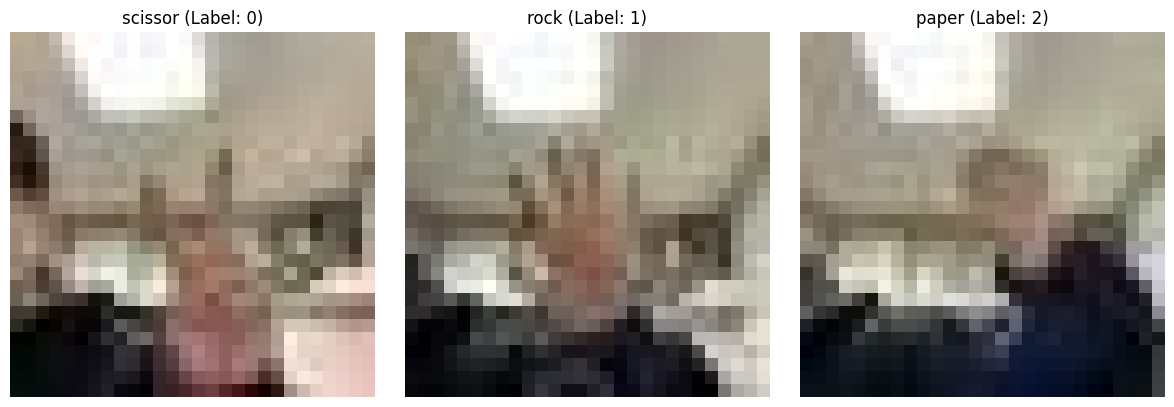

In [59]:
# 가위 (label: 0)
scissor2_imgs, _ = load_data('data/scissor2', 100)
scissor2_labels = np.zeros(100, dtype=np.int32)

# 바위 (label: 1)
rock2_imgs, _ = load_data('data/rock2', 100)
rock2_labels = np.ones(100, dtype=np.int32)

# 보 (label: 2)
paper2_imgs, _ = load_data('data/paper2', 100)
paper2_labels = np.full(100, 2, dtype=np.int32)

# 모든 데이터 병합
X2 = np.concatenate([scissor2_imgs, rock2_imgs, paper2_imgs], axis=0)
y2 = np.concatenate([scissor2_labels, rock2_labels, paper2_labels], axis=0)

print(f"All data shape: {X2.shape}")
print(f"All label shape: {y2.shape}")
print(f"label distribution: scissor={np.sum(y2==0)}, rock={np.sum(y2==1)}, paper={np.sum(y2==2)}")


# 데이터 시각화로 확인
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 각 클래스별로 하나씩 샘플 출력
axes[0].imshow(X2[0])
axes[0].set_title(f'scissor (Label: {y2[0]})')
axes[0].axis('off')

axes[1].imshow(X2[100])
axes[1].set_title(f'rock (Label: {y2[100]})')
axes[1].axis('off')

axes[2].imshow(X2[200])
axes[2].set_title(f'paper (Label: {y2[200]})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 딥러닝 네트워크 설계

In [60]:
n_channel_1 = 16
n_channel_2 = 32
n_dense = 32
n_train_epoch = 5

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3, 3), activation='relu', input_shape=(28, 28, 3)))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Conv2D(n_channel_2, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 26, 26, 16)        448       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 13, 13, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten_4 (Flatten)         (None, 800)               0         
                                                                 
 dense_8 (Dense)             (None, 32)               

In [61]:
model.fit(X2,y2, epochs = n_train_epoch)

Epoch 1/5
10/10 [==============================] - 0s 5ms/step - loss: 33.3097 - accuracy: 0.4133
Epoch 2/5
10/10 [==============================] - 0s 15ms/step - loss: 0.9074 - accuracy: 0.8733
Epoch 3/5
10/10 [==============================] - 0s 4ms/step - loss: 0.1873 - accuracy: 0.9667
Epoch 4/5
10/10 [==============================] - 0s 5ms/step - loss: 0.0398 - accuracy: 0.9933
Epoch 5/5
10/10 [==============================] - 0s 3ms/step - loss: 1.4245e-04 - accuracy: 1.0000


In [62]:
test_loss, test_accuracy = model.evaluate(X2, y2, verbose=2)
print("test_loss : {}".format(test_loss))
print("Test accuracy: {}".format(test_accuracy))

10/10 - 0s - loss: 6.9319e-04 - accuracy: 1.0000 - 60ms/epoch - 6ms/step
test_loss : 0.0006931910174898803
Test accuracy: 1.0


In [63]:
from sklearn.model_selection import train_test_split

# 모든 데이터 합치기
X_total = np.concatenate([X, X2], axis=0)
y_total = np.concatenate([y, y2], axis=0)

print(f"전체 데이터 shape: {X_total.shape}")
print(f"전체 레이블 shape: {y_total.shape}")
print(f"레이블 분포: 가위={np.sum(y_total==0)}, 바위={np.sum(y_total==1)}, 보={np.sum(y_total==2)}")

# 데이터 정규화 (0-255 -> 0-1)
X_total_normalized = X_total / 255.0

# 훈련/테스트 셋으로 다시 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_total_normalized, 
    y_total, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_total  # 각 클래스 비율을 유지하면서 분할
)

print(f"\n새로운 훈련 데이터: {X_train.shape}, {y_train.shape}")
print(f"새로운 테스트 데이터: {X_test.shape}, {y_test.shape}")

# 각 세트의 레이블 분포 확인
print(f"\n훈련 세트 레이블 분포:")
print(f"  가위={np.sum(y_train==0)}, 바위={np.sum(y_train==1)}, 보={np.sum(y_train==2)}")
print(f"테스트 세트 레이블 분포:")
print(f"  가위={np.sum(y_test==0)}, 바위={np.sum(y_test==1)}, 보={np.sum(y_test==2)}")

전체 데이터 shape: (600, 28, 28, 3)
전체 레이블 shape: (600,)
레이블 분포: 가위=200, 바위=200, 보=200

새로운 훈련 데이터: (480, 28, 28, 3), (480,)
새로운 테스트 데이터: (120, 28, 28, 3), (120,)

훈련 세트 레이블 분포:
  가위=160, 바위=160, 보=160
테스트 세트 레이블 분포:
  가위=40, 바위=40, 보=40


In [64]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
15/15 [==============================] - 0s 3ms/step - loss: 1.0635 - accuracy: 0.5708
Epoch 2/5
15/15 [==============================] - 0s 2ms/step - loss: 1.0062 - accuracy: 0.7083
Epoch 3/5
15/15 [==============================] - 0s 2ms/step - loss: 0.9116 - accuracy: 0.8687
Epoch 4/5
15/15 [==============================] - 0s 2ms/step - loss: 0.7756 - accuracy: 0.9458
Epoch 5/5
15/15 [==============================] - 0s 2ms/step - loss: 0.6321 - accuracy: 0.9646


In [65]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print("test_loss : {}".format(test_loss))
print("Test accuracy: {}".format(test_accuracy))

4/4 - 0s - loss: 0.6109 - accuracy: 0.9917 - 100ms/epoch - 25ms/step
test_loss : 0.6109186410903931
Test accuracy: 0.9916666746139526
